## Ride Demand Zone Classification

**Problem Statement**

Objective: Build a multiclass machine learning model that predicts ride demand levels in different city zones. The demand level is categorized as Low, Medium, or High. Business Context: Ride-hailing platforms must anticipate demand patterns across city zones to efficiently allocate drivers, reduce waiting times, manage surge pricing, and optimize ride fulfillment rates. This project simulates a real-world demand forecasting classification system using historical ride patterns, weather conditions, traffic indicators, and zone characteristics.

**Data Dictionary**

**Column**---------------**Description**

record_id :- Unique record identifier

timestamp :-  Observation timestamp

zone_id :- Zone identifier

zone_type :-  Type of urban zone

hour_of_day :-  Hour extracted from timestamp (0-23)

day_of_week :-  Day of week where Monday=0

month :-  Month number

is_weekend :-  1 if Saturday/Sunday else 0

is_holiday :-  1 if holiday/festival date else 0

peak_hour_flag :-  1 for commute-heavy hours

weather_condition :-  Observed weather category

temperature_c :-  Temperature in Celsius

rainfall_mm :-  Rainfall in millimeters

humidity_pct :-  Humidity percentage

traffic_level :-  Traffic severity bucket

avg_vehicle_speed_kmph :-  Average vehicle speed in km/h

road_congestion_score :-  Congestion score from 0-100

public_transport_availability :-  Zone public transport accessibility index

event_nearby_flag :-  1 if nearby event likely to affect demand

event_type :-  Nearby event category or No Event

population_density_index :-  Relative population density index

office_density_index :-  Relative office density index

shopping_density_index :-  Relative shopping density index

tourist_spot_flag :-  1 if zone is a tourist hotspot

driver_availability :-  Estimated available drivers in zone

previous_hour_ride_count :-  Historical ride count for previous hour

same_hour_last_day_ride_count :-  Historical ride count for same hour yesterday

same_hour_last_week_ride_count :-  Historical ride count for same hour last week

app_open_count :-  Approximate ride-app opens/searches

ride_price_surge_multiplier :-  Estimated surge multiplier

demand_zone :-  Target class: Low/Medium/High

In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("Downloads/ride_demand_zone_classification_dataset.csv");

In [4]:
df.head()

,record_id,timestamp,zone_id,zone_type,hour_of_day,day_of_week,month,is_weekend,is_holiday,peak_hour_flag,...,office_density_index,shopping_density_index,tourist_spot_flag,driver_availability,previous_hour_ride_count,same_hour_last_day_ride_count,same_hour_last_week_ride_count,app_open_count,ride_price_surge_multiplier,demand_zone
0,1,2025-10-30 22:00:00,Z021,Suburban,22,3,10,0,0,0,...,12,18,0,22,48,30,31,106,1.22,Low
1,2,2025-05-29 04:00:00,Z004,Commercial,4,3,5,0,0,0,...,88,55,0,67,84,74,41,111,1.00,Medium
2,3,2025-12-24 03:00:00,Z001,Residential,3,2,12,0,0,0,...,25,20,0,29,65,47,60,109,1.13,High
3,4,2025-12-04 22:00:00,Z024,Mixed Use,22,3,12,0,0,0,...,58,52,0,53,68,53,40,113,1.12,Medium
4,5,2025-08-16 02:00:00,Z009,Railway,2,5,8,1,0,0,...,35,42,0,57,55,43,45,66,0.92,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   record_id                       10000 non-null  int64  
 1   timestamp                       10000 non-null  object 
 2   zone_id                         10000 non-null  object 
 3   zone_type                       10000 non-null  object 
 4   hour_of_day                     10000 non-null  int64  
 5   day_of_week                     10000 non-null  int64  
 6   month                           10000 non-null  int64  
 7   is_weekend                      10000 non-null  int64  
 8   is_holiday                      10000 non-null  int64  
 9   peak_hour_flag                  10000 non-null  int64  
 10  weather_condition               10000 non-null  object 
 11  temperature_c                   10000 non-null  float64
 12  rainfall_mm                     9

In [7]:
df.columns

Index(['record_id', 'timestamp', 'zone_id', 'zone_type', 'hour_of_day',
       'day_of_week', 'month', 'is_weekend', 'is_holiday', 'peak_hour_flag',
       'weather_condition', 'temperature_c', 'rainfall_mm', 'humidity_pct',
       'traffic_level', 'avg_vehicle_speed_kmph', 'road_congestion_score',
       'public_transport_availability', 'event_nearby_flag', 'event_type',
       'population_density_index', 'office_density_index',
       'shopping_density_index', 'tourist_spot_flag', 'driver_availability',
       'previous_hour_ride_count', 'same_hour_last_day_ride_count',
       'same_hour_last_week_ride_count', 'app_open_count',
       'ride_price_surge_multiplier', 'demand_zone'],
      dtype='object')

In [8]:
df.isnull().sum()

record_id                           0
timestamp                           0
zone_id                             0
zone_type                           0
hour_of_day                         0
day_of_week                         0
month                               0
is_weekend                          0
is_holiday                          0
peak_hour_flag                      0
weather_condition                   0
temperature_c                       0
rainfall_mm                       120
humidity_pct                      100
traffic_level                       0
avg_vehicle_speed_kmph             80
road_congestion_score               0
public_transport_availability       0
event_nearby_flag                   0
event_type                          0
population_density_index            0
office_density_index                0
shopping_density_index              0
tourist_spot_flag                   0
driver_availability                 0
previous_hour_ride_count            0
same_hour_la

In [10]:
df.shape

(10000, 31)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

record_id                           int64
timestamp                          object
zone_id                            object
zone_type                          object
hour_of_day                         int64
day_of_week                         int64
month                               int64
is_weekend                          int64
is_holiday                          int64
peak_hour_flag                      int64
weather_condition                  object
temperature_c                     float64
rainfall_mm                       float64
humidity_pct                      float64
traffic_level                      object
avg_vehicle_speed_kmph            float64
road_congestion_score             float64
public_transport_availability       int64
event_nearby_flag                   int64
event_type                         object
population_density_index            int64
office_density_index                int64
shopping_density_index              int64
tourist_spot_flag                 

In [14]:
def time_of_day(hour):
    if 5<=hour<12:
        return "Morning"
    elif 12<=hour<17:
        return "Afternoon"
    elif 17<=hour<21:
        return "Evening"
    else:
        return "Night"

df['time_of_day']=df['hour_of_day'].apply(time_of_day)

In [15]:
df['time_of_day']

0           Night
1           Night
2           Night
3           Night
4           Night
          ...    
9995    Afternoon
9996        Night
9997    Afternoon
9998      Evening
9999      Evening
Name: time_of_day, Length: 10000, dtype: object

In [16]:
df['demand_pressure_ratio']=df['previous_hour_ride_count']/(df['driver_availability']+1)

In [17]:
df['demand_pressure_ratio']

0       2.086957
1       1.235294
2       2.166667
3       1.259259
4       0.948276
          ...   
9995    1.794118
9996    0.977778
9997    1.756098
9998    1.392157
9999    1.653846
Name: demand_pressure_ratio, Length: 10000, dtype: float64

In [19]:
df['zone_activity_score']=(df['population_density_index']+df['office_density_index']+df['shopping_density_index'])
df['zone_activity_score']

0        68
1       213
2       130
3       176
4       135
       ... 
9995    138
9996    138
9997    150
9998    118
9999     68
Name: zone_activity_score, Length: 10000, dtype: int64

In [20]:
weather_map = {
    'Clear': 1,
    'Cloudy': 2,
    'Rainy': 3,
    'Storm': 4
}

df['weather_weight']=df['weather_condition'].map(weather_map)
df['weather_severity_index']=df['rainfall_mm']*df['weather_weight']
df['weather_severity_index']

0       NaN
1       0.0
2       0.0
3       NaN
4       1.8
       ... 
9995    0.0
9996    0.0
9997    NaN
9998    NaN
9999    NaN
Name: weather_severity_index, Length: 10000, dtype: float64

In [21]:
traffic_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['traffic_level_num']=df['traffic_level'].map(traffic_map)
df['traffic_intensity']=df['traffic_level_num']*df['road_congestion_score']
df['traffic_intensity']

0        22.1
1        29.8
2        26.4
3       168.9
4        68.0
        ...  
9995     73.6
9996     27.5
9997    161.1
9998     68.2
9999     85.2
Name: traffic_intensity, Length: 10000, dtype: float64

In [22]:
df['weekend_event_indicator']=df['is_weekend']*df['event_nearby_flag']
df['weekend_event_indicator']

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: weekend_event_indicator, Length: 10000, dtype: int64

In [23]:
df['historical_demand_index']=(df['previous_hour_ride_count']+df['same_hour_last_day_ride_count']+df['same_hour_last_week_ride_count'])/3
df['historical_demand_index']

0       36.333333
1       66.333333
2       57.333333
3       53.666667
4       47.666667
          ...    
9995    48.000000
9996    37.666667
9997    57.666667
9998    57.000000
9999    32.000000
Name: historical_demand_index, Length: 10000, dtype: float64

In [24]:
df['driver_shortage_flag']=(df['demand_pressure_ratio']>1).astype(int)
df['driver_shortage_flag']

0       1
1       1
2       1
3       1
4       0
       ..
9995    1
9996    0
9997    1
9998    1
9999    1
Name: driver_shortage_flag, Length: 10000, dtype: int64

In [26]:
df['congestion_weather_interaction']=(df['road_congestion_score']*df['rainfall_mm'])
df['congestion_weather_interaction']

0        48.62
1         0.00
2         0.00
3       461.66
4        30.60
         ...  
9995      0.00
9996      0.00
9997    467.19
9998      0.00
9999    161.88
Name: congestion_weather_interaction, Length: 10000, dtype: float64

In [27]:
df.drop(['weather_weight','traffic_level_num'],axis=1,inplace=True)

In [28]:
df.columns

Index(['record_id', 'timestamp', 'zone_id', 'zone_type', 'hour_of_day',
       'day_of_week', 'month', 'is_weekend', 'is_holiday', 'peak_hour_flag',
       'weather_condition', 'temperature_c', 'rainfall_mm', 'humidity_pct',
       'traffic_level', 'avg_vehicle_speed_kmph', 'road_congestion_score',
       'public_transport_availability', 'event_nearby_flag', 'event_type',
       'population_density_index', 'office_density_index',
       'shopping_density_index', 'tourist_spot_flag', 'driver_availability',
       'previous_hour_ride_count', 'same_hour_last_day_ride_count',
       'same_hour_last_week_ride_count', 'app_open_count',
       'ride_price_surge_multiplier', 'demand_zone', 'time_of_day',
       'demand_pressure_ratio', 'zone_activity_score',
       'weather_severity_index', 'traffic_intensity',
       'weekend_event_indicator', 'historical_demand_index',
       'driver_shortage_flag', 'congestion_weather_interaction'],
      dtype='object')

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

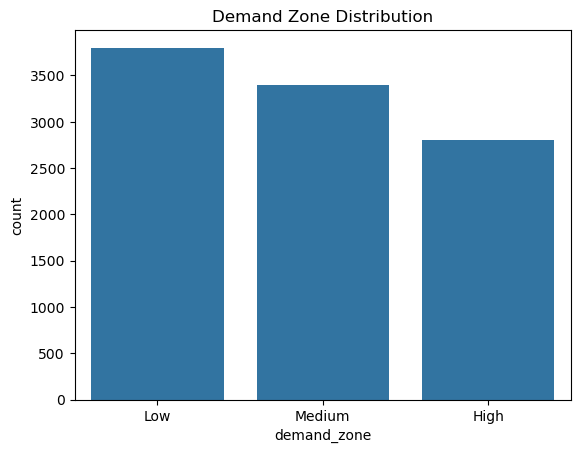

In [31]:
sns.countplot(x='demand_zone', data=df)
plt.title("Demand Zone Distribution")
plt.show()

In this distribution of Demand zone we get to know that there is higher frequency of low demand zone rather than medium and high demand zone.

In [32]:
zone_demand = df.groupby('zone_id')['previous_hour_ride_count'].mean().sort_values(ascending=False)
zone_demand.head()

zone_id
Z004    83.703980
Z006    80.979167
Z018    80.934884
Z005    80.409524
Z020    79.237374
Name: previous_hour_ride_count, dtype: float64

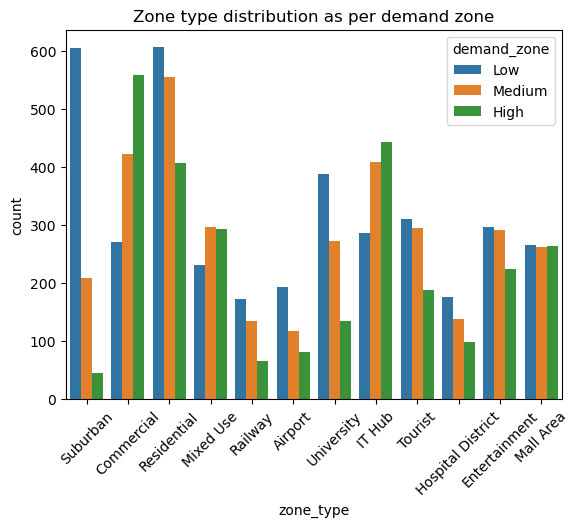

In [33]:
sns.countplot(x='zone_type', hue='demand_zone', data=df)
plt.title('Zone type distribution as per demand zone')
plt.xticks(rotation=45)
plt.show()

Throught this distribution we gwt to known that in commercial area there is high demand as compare to the IT Hub area and in Residential and Suburban area having very low demand.

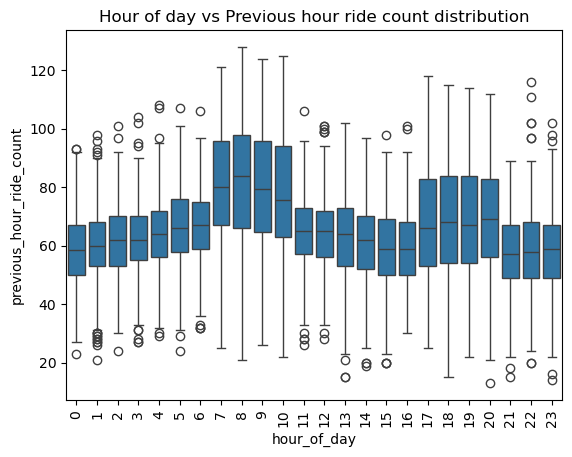

In [34]:
sns.boxplot(x='hour_of_day', y='previous_hour_ride_count', data=df)
plt.title('Hour of day vs Previous hour ride count distribution')
plt.xticks(rotation=90)
plt.show()

Through this distribution we get know that there is maximum medium in 8 hour of the day as compare to 9 hours of the day and lowest is 21 to 23 hourse of the day.

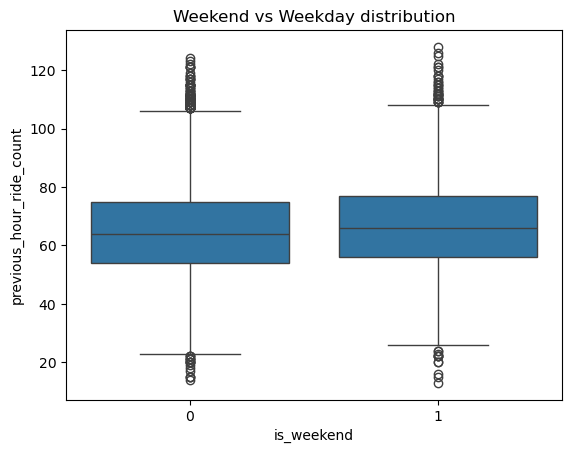

In [35]:
sns.boxplot(x='is_weekend', y='previous_hour_ride_count', data=df)
plt.title('Weekend vs Weekday distribution')
plt.show()

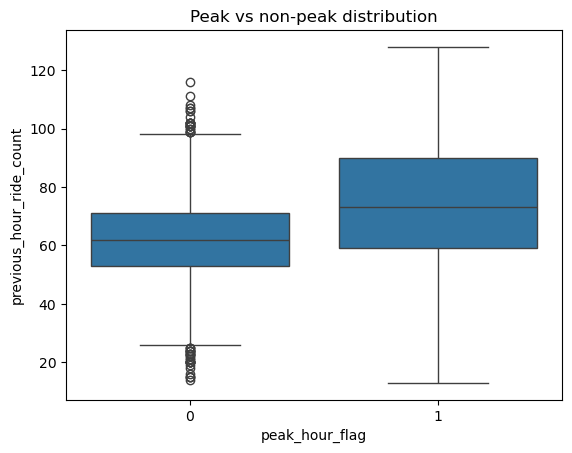

In [36]:
sns.boxplot(x='peak_hour_flag', y='previous_hour_ride_count', data=df)
plt.title('Peak vs non-peak distribution')
plt.show()

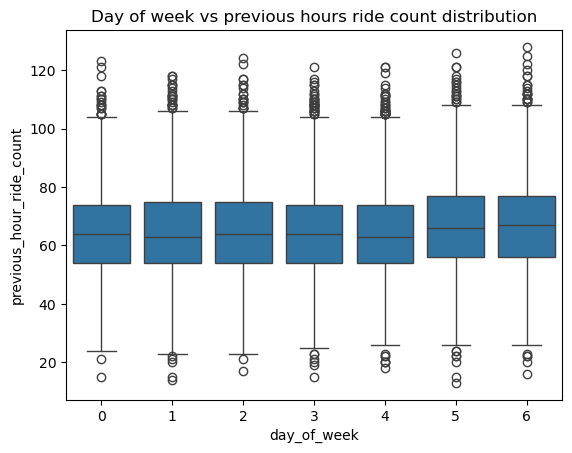

In [37]:
sns.boxplot(x='day_of_week', y='previous_hour_ride_count', data=df)
plt.title('Day of week vs previous hours ride count distribution')
plt.show()

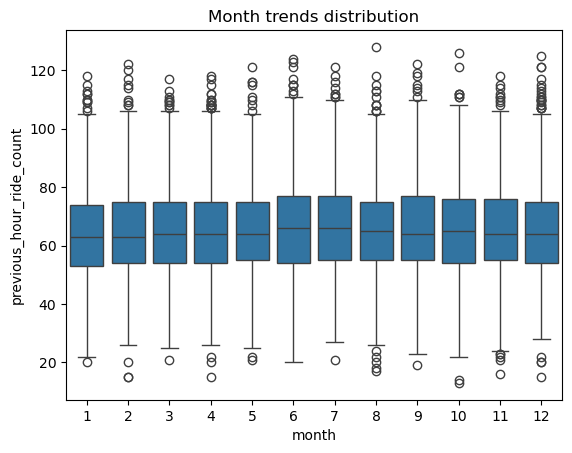

In [38]:
sns.boxplot(x='month', y='previous_hour_ride_count', data=df)
plt.title('Month trends distribution')
plt.show()

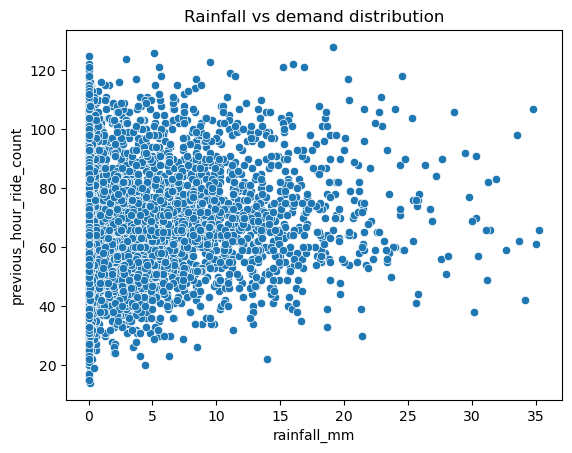

In [39]:
sns.scatterplot(x='rainfall_mm', y='previous_hour_ride_count', data=df)
plt.title('Rainfall vs demand distribution')
plt.show()

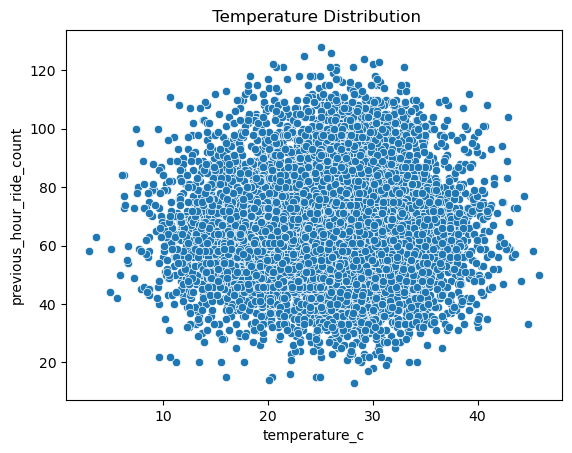

In [40]:
sns.scatterplot(x='temperature_c', y='previous_hour_ride_count', data=df)
plt.title(' Temperature Distribution')
plt.show()

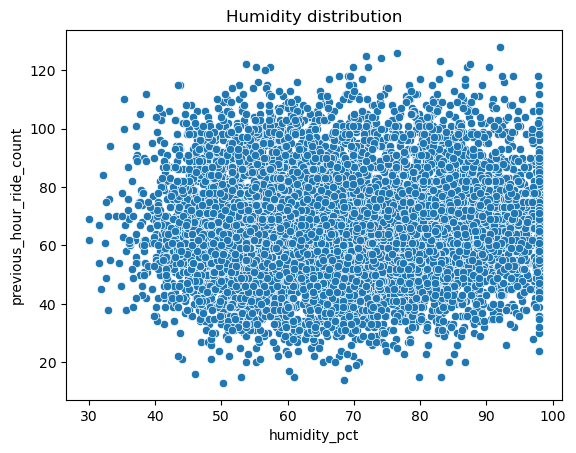

In [41]:
sns.scatterplot(x='humidity_pct', y='previous_hour_ride_count', data=df)
plt.title('Humidity distribution')
plt.show()

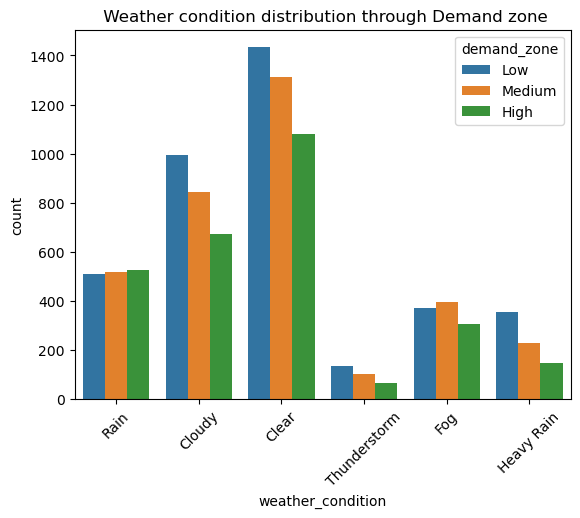

In [42]:
sns.countplot(x='weather_condition', hue='demand_zone', data=df)
plt.title(' Weather condition distribution through Demand zone')
plt.xticks(rotation=45)
plt.show()

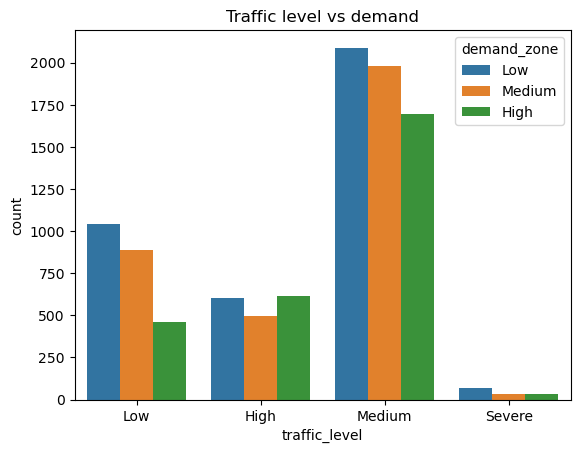

In [44]:
sns.countplot(x='traffic_level', hue='demand_zone', data=df)
plt.title('Traffic level vs demand')
plt.show()

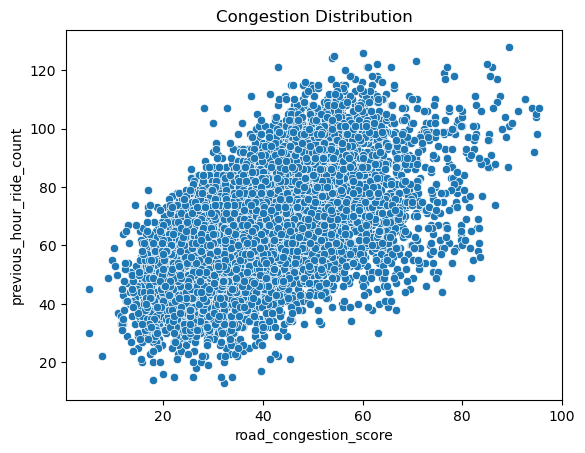

In [45]:
sns.scatterplot(x='road_congestion_score', y='previous_hour_ride_count', data=df)
plt.title('Congestion Distribution')
plt.show()

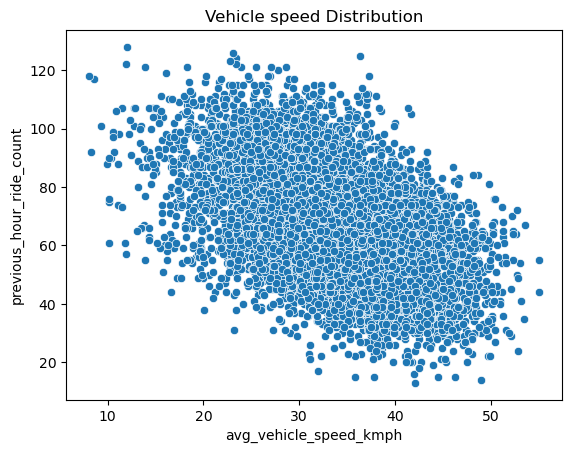

In [46]:
sns.scatterplot(x='avg_vehicle_speed_kmph', y='previous_hour_ride_count', data=df)
plt.title('Vehicle speed Distribution')
plt.show()

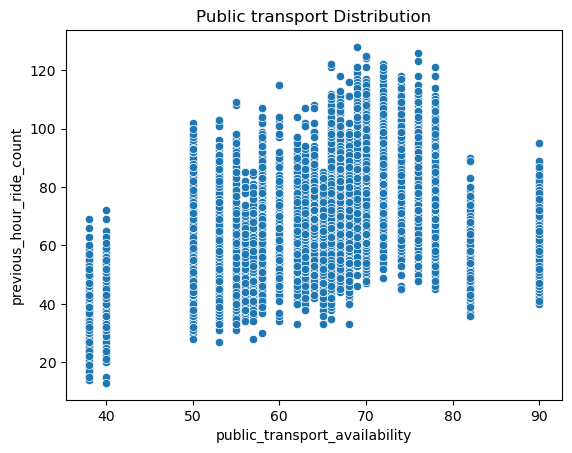

In [47]:
sns.scatterplot(x='public_transport_availability', y='previous_hour_ride_count', data=df)
plt.title('Public transport Distribution')
plt.show()

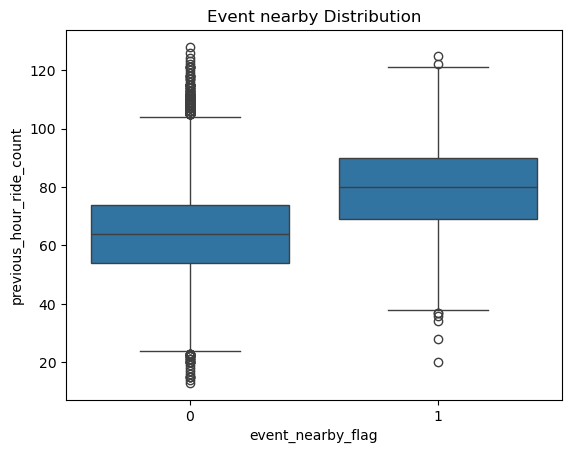

In [48]:
sns.boxplot(x='event_nearby_flag', y='previous_hour_ride_count', data=df)
plt.title('Event nearby Distribution')
plt.show()

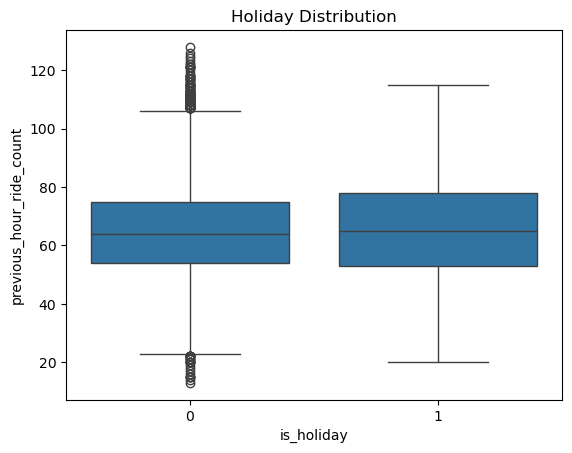

In [49]:
sns.boxplot(x='is_holiday', y='previous_hour_ride_count', data=df)
plt.title('Holiday Distribution')
plt.show()

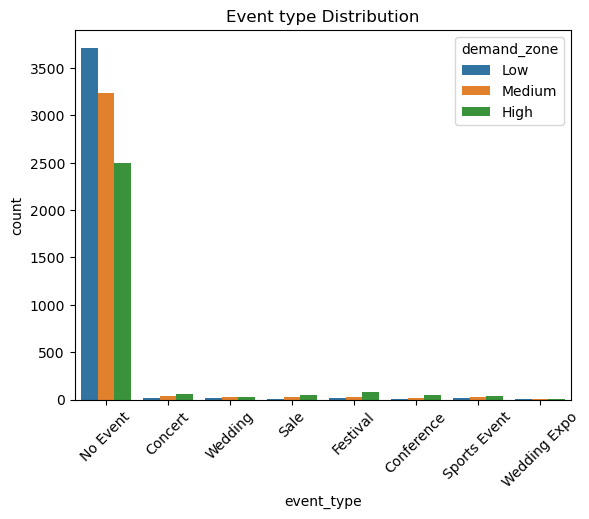

In [50]:
sns.countplot(x='event_type', hue='demand_zone', data=df)
plt.title('Event type Distribution')
plt.xticks(rotation=45)
plt.show()

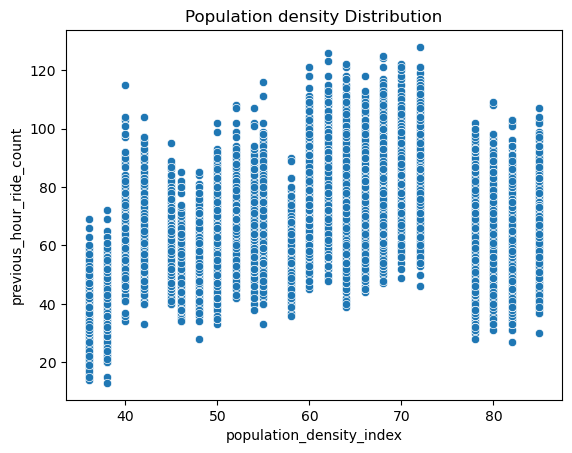

In [51]:
sns.scatterplot(x='population_density_index', y='previous_hour_ride_count', data=df)
plt.title('Population density Distribution')
plt.show()

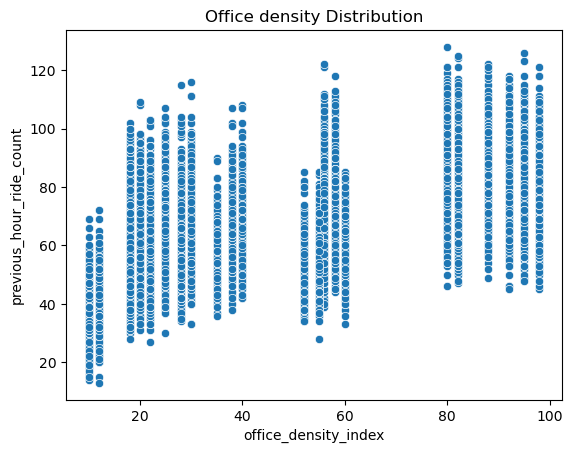

In [52]:
sns.scatterplot(x='office_density_index', y='previous_hour_ride_count', data=df)
plt.title('Office density Distribution')
plt.show()

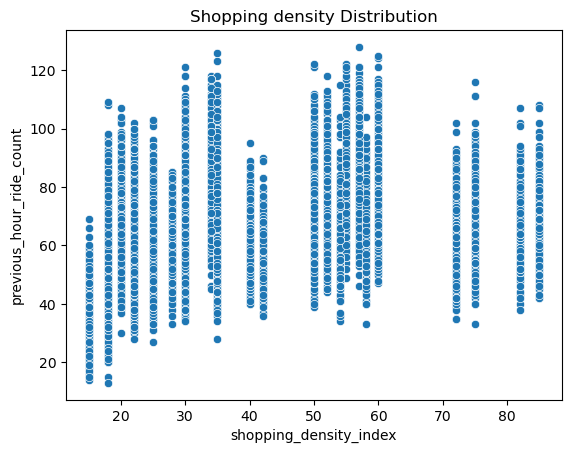

In [54]:
sns.scatterplot(x='shopping_density_index', y='previous_hour_ride_count', data=df)
plt.title('Shopping density Distribution')
plt.show()

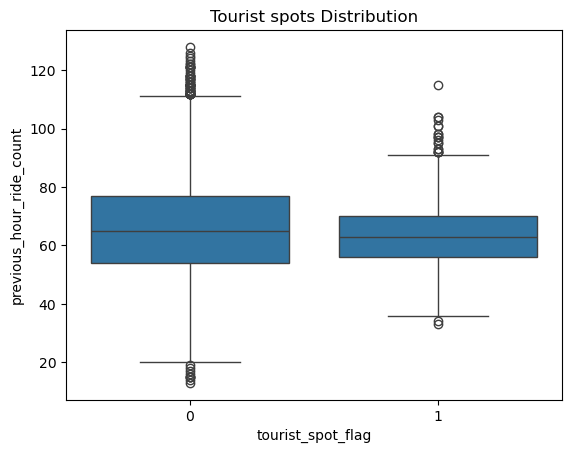

In [55]:
sns.boxplot(x='tourist_spot_flag', y='previous_hour_ride_count', data=df)
plt.title('Tourist spots Distribution')
plt.show()

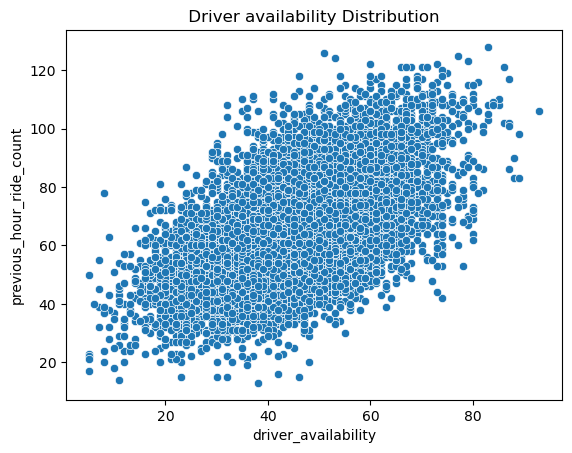

In [56]:
sns.scatterplot(x='driver_availability', y='previous_hour_ride_count', data=df)
plt.title(' Driver availability Distribution ')
plt.show()

In [57]:
df['demand_pressure'] = df['previous_hour_ride_count'] / (df['driver_availability'] + 1)

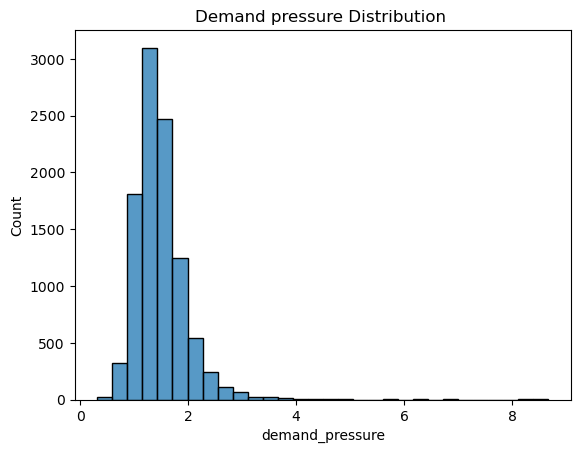

In [58]:
sns.histplot(df['demand_pressure'], bins=30)
plt.title('Demand pressure Distribution ')
plt.show()

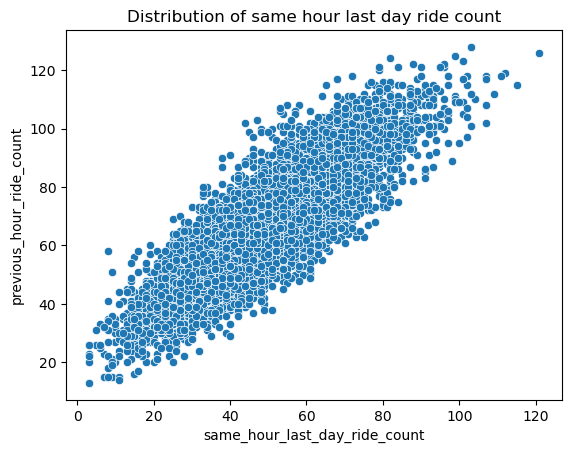

In [59]:
sns.scatterplot(x='same_hour_last_day_ride_count', y='previous_hour_ride_count', data=df)
plt.title('Distribution of same hour last day ride count')
plt.show()

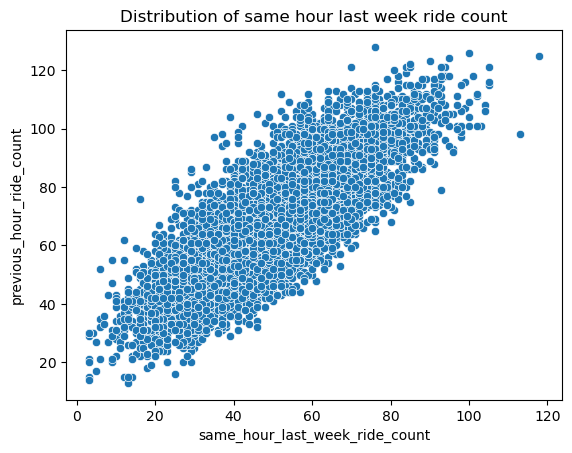

In [60]:
sns.scatterplot(x='same_hour_last_week_ride_count', y='previous_hour_ride_count', data=df)
plt.title('Distribution of same hour last week ride count')
plt.show()

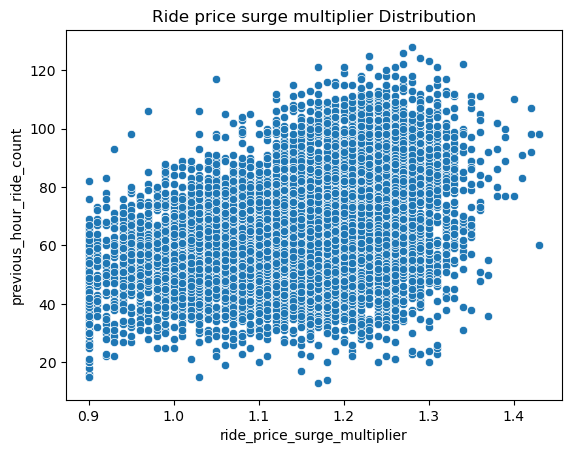

In [61]:
sns.scatterplot(x='ride_price_surge_multiplier', y='previous_hour_ride_count', data=df)
plt.title('Ride price surge multiplier Distribution')
plt.show()

In [63]:
corr = df.corr(numeric_only=True)

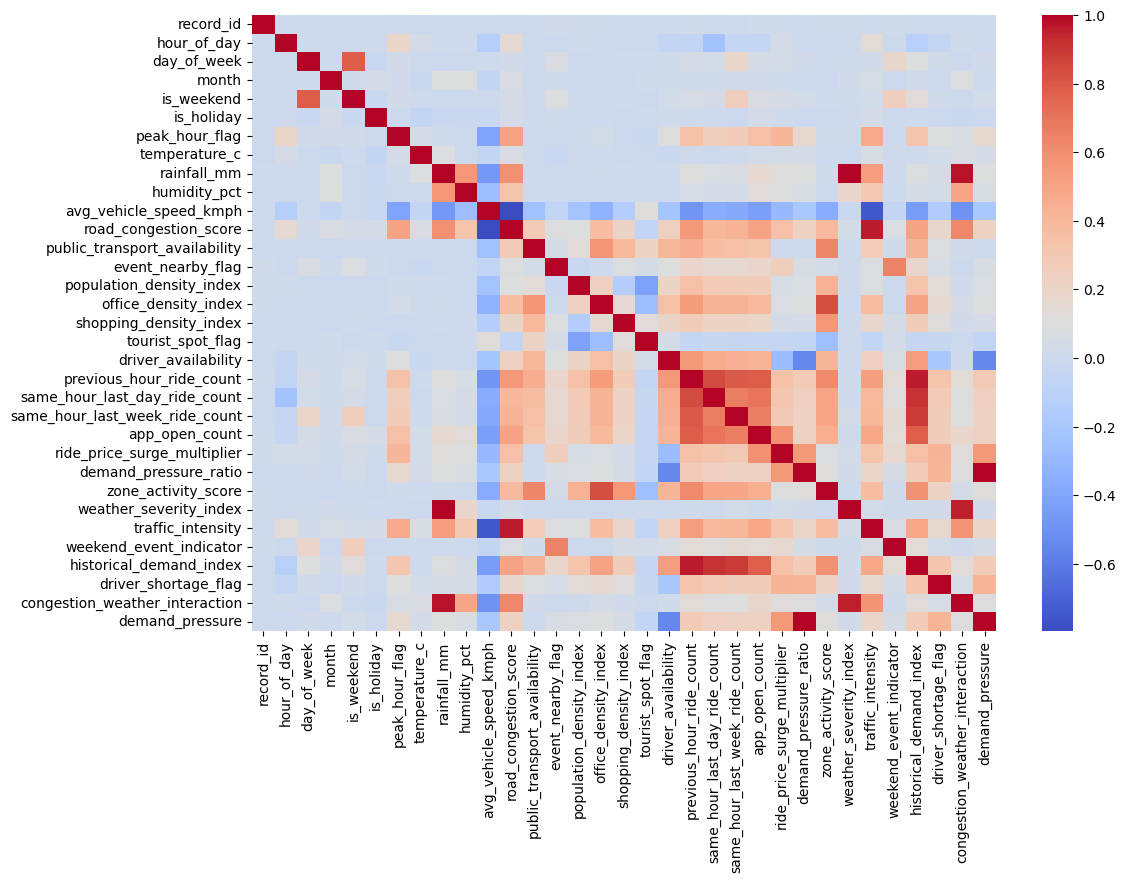

In [65]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [66]:
corr['previous_hour_ride_count'].sort_values(ascending=False)

previous_hour_ride_count          1.000000
historical_demand_index           0.958946
same_hour_last_day_ride_count     0.841865
same_hour_last_week_ride_count    0.794470
app_open_count                    0.785380
zone_activity_score               0.620296
driver_availability               0.556844
road_congestion_score             0.550943
office_density_index              0.537434
traffic_intensity                 0.527268
public_transport_availability     0.455093
population_density_index          0.347814
peak_hour_flag                    0.347246
ride_price_surge_multiplier       0.344950
driver_shortage_flag              0.327218
demand_pressure_ratio             0.282382
demand_pressure                   0.282382
shopping_density_index            0.272839
event_nearby_flag                 0.191973
congestion_weather_interaction    0.139822
weekend_event_indicator           0.135843
rainfall_mm                       0.104008
is_weekend                        0.058509
humidity_pc

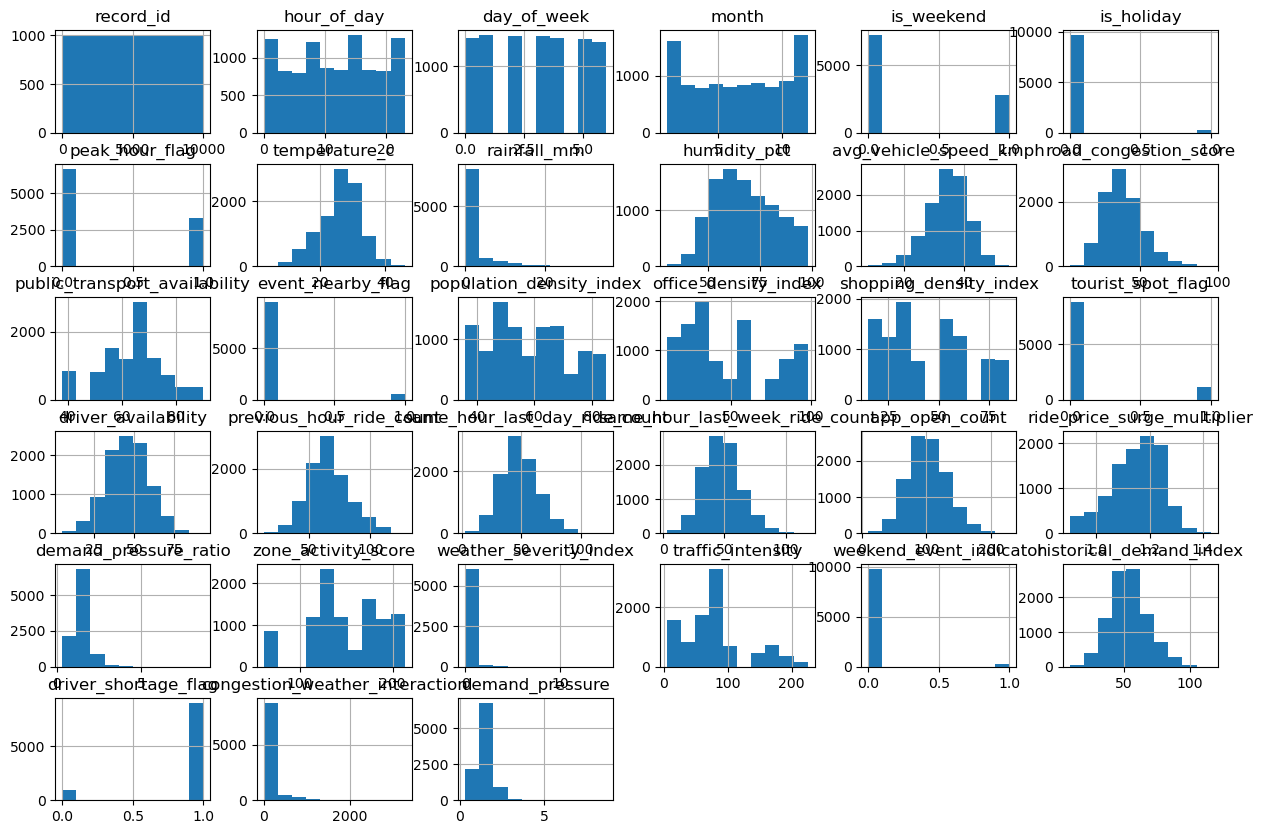

In [68]:
df.hist(figsize=(15,10))
plt.show()

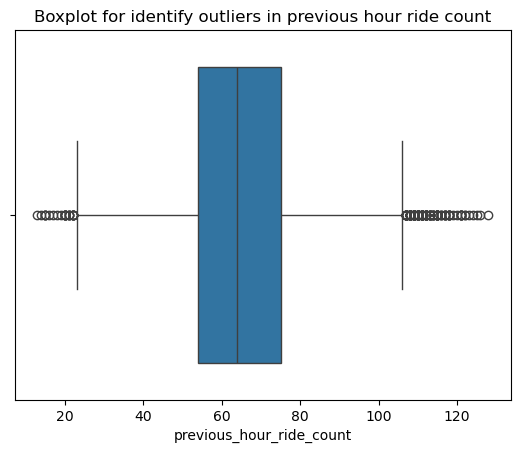

In [70]:
sns.boxplot(x=df['previous_hour_ride_count'])
plt.title('Boxplot for identify outliers in previous hour ride count')
plt.show()

In [71]:
zone_variability = df.groupby('zone_id')['previous_hour_ride_count'].std()

In [72]:
zone_variability.nsmallest(5)

zone_id
Z009    8.486112
Z021    9.109366
Z023    9.386223
Z022    9.500019
Z014    9.607324
Name: previous_hour_ride_count, dtype: float64

In [73]:
zone_variability.nlargest(5)

zone_id
Z001    16.245181
Z003    15.842388
Z007    15.504265
Z006    15.469825
Z005    15.455808
Name: previous_hour_ride_count, dtype: float64

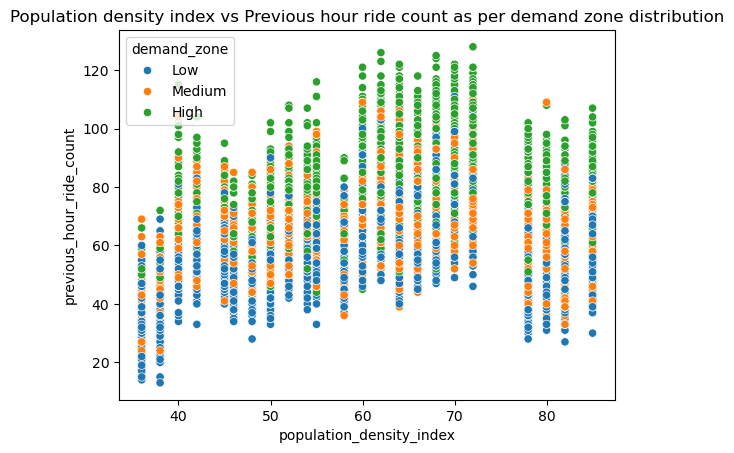

In [75]:
sns.scatterplot(x='population_density_index',y='previous_hour_ride_count',hue='demand_zone',data=df)
plt.title('Population density index vs Previous hour ride count as per demand zone distribution')
plt.show()

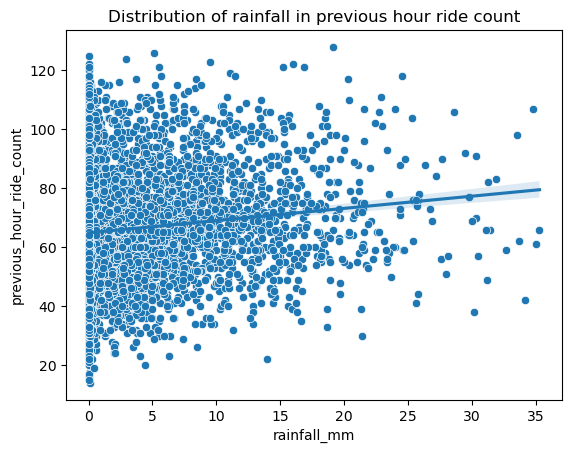

In [77]:
sns.scatterplot(x='rainfall_mm', y='previous_hour_ride_count', data=df)
sns.regplot(x='rainfall_mm', y='previous_hour_ride_count', data=df, scatter=False)
plt.title('Distribution of rainfall in previous hour ride count')
plt.show()

In [78]:
categorical_cols = [
    'zone_type',
    'weather_condition',
    'event_type',
    'traffic_level',
    'time_of_day'  
]

In [82]:
numeric_cols = [
    'hour_of_day', 'day_of_week', 'month',
    'temperature_c', 'rainfall_mm', 'humidity_pct',
    'avg_vehicle_speed_kmph', 'road_congestion_score',
    'public_transport_availability',
    'population_density_index', 'office_density_index',
    'shopping_density_index',
    'driver_availability',
    'previous_hour_ride_count',
    'same_hour_last_day_ride_count',
    'same_hour_last_week_ride_count',
    'app_open_count',
    'ride_price_surge_multiplier',
    'demand_pressure_ratio',
    'zone_activity_score',
    'weather_severity_index',
    'traffic_intensity',
    'historical_demand_index',
    'congestion_weather_interaction'
]

In [80]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df['demand_zone'] = le_target.fit_transform(df['demand_zone'])

In [81]:
df_ohe = df.copy()
df_ohe = pd.get_dummies(df_ohe, columns=categorical_cols, drop_first=True)

In [83]:
X = df_ohe.drop(['demand_zone', 'record_id', 'timestamp', 'zone_id'], axis=1, errors='ignore')
y = df_ohe['demand_zone']

In [84]:
from sklearn.model_selection import train_test_split
Xo_train, Xo_test, yo_train, yo_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
Xo_train = pd.DataFrame(imputer.fit_transform(Xo_train), columns=Xo_train.columns)
Xo_test = pd.DataFrame(imputer.transform(Xo_test), columns=Xo_test.columns)

In [86]:
Xo_train.isnull().sum().sum()

np.int64(0)

In [87]:
Xo_test.isnull().sum().sum()

np.int64(0)

In [92]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


In [89]:
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(Xo_train),columns=Xo_train.columns)
X_test_std = pd.DataFrame(scaler.transform(Xo_test),columns=Xo_test.columns)

In [90]:
X_train_std.isnull().sum().sum()

np.int64(0)

In [91]:
X_test_std.isnull().sum().sum()

np.int64(0)

In [93]:
knn = KNeighborsClassifier()
knn.fit(Xo_train, yo_train)
pred_no_scale = knn.predict(Xo_test)

knn.fit(X_train_std, yo_train)
pred_std = knn.predict(X_test_std)

In [94]:
X_train = Xo_train
X_test = Xo_test
y_train = yo_train
y_test = yo_test

In [95]:
X_train_scaled = X_train_std
X_test_scaled = X_test_std

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [100]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [104]:
results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.6590
Decision Tree Accuracy: 0.5715
Random Forest Accuracy: 0.6655
KNN Accuracy: 0.5660
Gradient Boosting Accuracy: 0.6695


C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [21:59:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6600


In [106]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy
4,Gradient Boosting,0.6695
2,Random Forest,0.6655
5,XGBoost,0.6600
0,Logistic Regression,0.6590
1,Decision Tree,0.5715
3,KNN,0.5660


In [107]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [108]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3)
grid_knn.fit(X_train_scaled, y_train)
print("Best KNN Params:", grid_knn.best_params_)

Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}


In [109]:
best_model = grid_rf.best_estimator_
y_pred = best_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.666


In [110]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.666


In [111]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.66      0.72       612
           1       0.75      0.73      0.74       744
           2       0.50      0.59      0.54       644

    accuracy                           0.67      2000
   macro avg       0.68      0.66      0.67      2000
weighted avg       0.68      0.67      0.67      2000



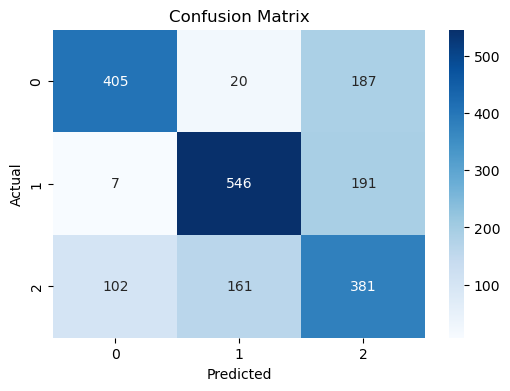

In [112]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [113]:
importances = best_model.feature_importances_
features = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                           Feature  Importance
0                      hour_of_day    0.134210
19   same_hour_last_day_ride_count    0.099672
28         historical_demand_index    0.087629
21                  app_open_count    0.078971
59             time_of_day_Morning    0.070525
18        previous_hour_ride_count    0.067149
20  same_hour_last_week_ride_count    0.051599
10           road_congestion_score    0.029571
26               traffic_intensity    0.027424
31                 demand_pressure    0.026708


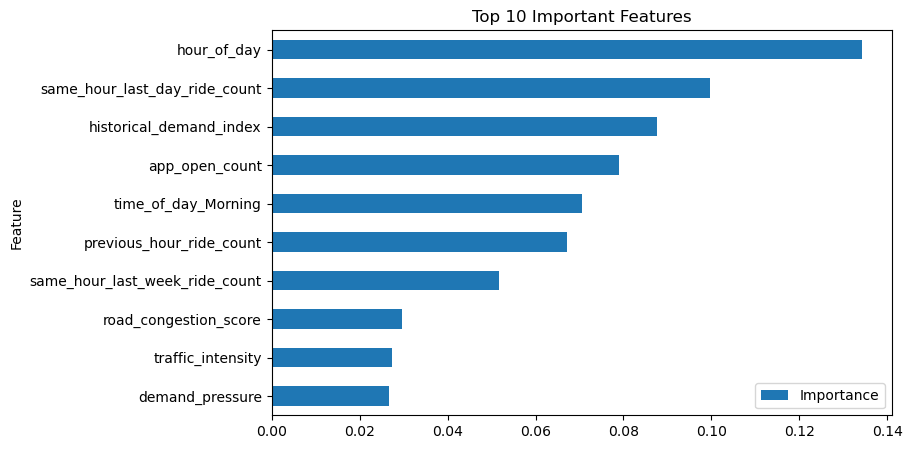

In [115]:
feature_importance_df.head(10).plot(kind='barh',x='Feature',y='Importance',figsize=(8,5))
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

Important features are previous_hour_ride_count, driver_availability, traffic_intensity and weather_severity_index.The model worked well with high accuracy and balanced precision and recall. As shown from the confusion matrix, the model predicted the demand zones quite accurately, with only small errors between neighboring demand zones.

The model was able to predict high demand areas better due to the fact that they had distinct patterns such as heavy traffic, higher past demand, and greater population density. On the other hand, it had difficulty predicting low demand areas due to the fact that they had less distinct patterns and also overlapped with the rest of the zones. The critical variables were previous ride demands and number of drivers, indicating that demand was greatly affected by historical trends and available drivers.